In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as f
import torchvision
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from torchvision import models
from torch.utils.data import random_split, Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
# CIFAR-10 이미지 데이터 활용
# Horizontal flip 적용(train data)

data_dir = "./data"
batch_size = 128

cifar_mean = [0.4914, 0.4822, 0.4465]

# train data -> 32 * 32 size에 padding 4를 적용하고 랜덤하게 32 * 32 크기로 사진을 잘라서 사용함
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=[0.2470, 0.2435, 0.2616]),
])

# train data를 45000 : 5000으로 나누어서 검증데이터로 활용
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=[0.2470, 0.2435, 0.2616])
])

# test data -> 사진을 그대로 사용
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=[0.2470, 0.2435, 0.2616]),
])


In [ ]:
train_dataset = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=train_transform)
val_dataset = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=val_transform)
test_dataset = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=test_transform)

# train, validation index 기반 데이터 분리
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(
    range(len(train_dataset)),
    [45000, 5000],
    generator=generator
)

train_dataset = Subset(train_dataset, train_subset.indices)
val_dataset = Subset(val_dataset, val_subset.indices)

'''
batch_size : 모델에 한번에 얼마나 많은 데이터를 넣을지
shuffle : 각 epoch마다 데이터 순서를 바꿈
pin_memory : pinned memory를 사용해 gpu로 데이터 빠르게 복사
'''
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle = False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"test batches: {len(test_loader)}")

100%|██████████| 170M/170M [00:05<00:00, 30.2MB/s]


Train batches: 352
Val batches: 40
test batches: 79


### Resnet(CIFAR)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Option A
# 채널이 달라지는 구간에서 논문의 Option A 방법 사용
# Option A : 부족한 채널의 깊이를 0으로 padding 해 shortcut의 채널의 깊이를 맞춘다.
class Shortcut_cls(nn.Module) :
    def __init__(self, cin, cout) :
        super().__init__()
        self.padded = cout - cin

    def forward(self, x) :
        out = x
        out = out[:, :, ::2, ::2]
        b, _, h, w = out.shape
        zero_padding = torch.zeros(b, self.padded, h, w,
                                    dtype = out.dtype,
                                    device = out.device)
        # torch.zeros 는 cpu에서 연산을 수행하는데
        # 모델 학습을 GPU에서 수행될 시 메모리 공간이 달라서 에러가 발생할 수 있다.
        out = torch.cat([out, zero_padding],
                        dim = 1 ) # 채널기준으로 합침
        return out


# 동일차원 출력
class BasicBlock(nn.Module):
    """
    ResNet basic block (CIFAR style):
    F(x) = conv3x3 -> BN -> ReLU -> conv3x3 -> BN
    y = ReLU( F(x) + x ) : identity shortcut 사용
    """
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        # batch normalization을 사용하므로 conv bias = False
        # batch normalization에서 정규화 이후 γx + β 연산을 수행하게 된다.
        # 이때 convolution에서 bias를 활용해도 이후 bn 단계에서 그 효과가 거의 사라지고 학습 파라미터만 늘리게 된다.
        # 처음 feature가 줄어들 때 stride를 2로 설정
        self.conv1 = nn.Conv2d(in_channels=cin,
                                out_channels= cout,
                                kernel_size=3,
                                stride=stride,
                                padding=1,
                                bias = False )
        self.bn1 = nn.BatchNorm2d(cout)

        self.conv2 = nn.Conv2d(in_channels=cout,
                                out_channels= cout,
                                kernel_size=3,
                                stride=1,
                                padding=1,
                                bias = False )
        self.bn2 = nn.BatchNorm2d(cout)

        self.relu = nn.ReLU()
        if cin != cout or stride == 2:
            self.shortcut = Shortcut_cls(cin, cout)
        else :
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + self.shortcut(x)
        out = self.relu(out)

        return out

def _make_stage(n, cin, cout, stride) :
    layers = []
    layers.append(BasicBlock(cin, cout, stride))

    for _ in range(n - 1) :
        layers.append(BasicBlock(cout, cout))

    return nn.Sequential(*layers)


class CustomResNet(nn.Module):
    '''
    3 * 32 * 32 -> 16 * 32 * 32
    16  * 32 * 32 -> 32 * 16 * 16
    32 * 16 * 16 -> 64 * 8 * 8
    FCL
    '''
    def __init__(self, n) :
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels= 3,
            out_channels= 16,
            stride = 1,
            kernel_size= 3,
            padding = 1,
            bias = False
            )
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU()

        self.stage1 = _make_stage(n, 16, 16, 1)
        self.stage2 = _make_stage(n, 16, 32, 2)
        self.stage3 = _make_stage(n, 32, 64, 2)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fcl = nn.Linear(64, 10)


    def forward(self, x) :
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.stage1(out)
        out = self.stage2(out)
        out = self.stage3(out)
        out = self.gap(out)
        out = torch.flatten(out, 1)
        out = self.fcl(out)
        return out

model = CustomResNet(n = 5).to(device)

In [ ]:
from torch.optim.lr_scheduler import MultiStepLR

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr = 0.1,
    momentum = 0.9,
    weight_decay = 1e-4
)

# 특정 epoch에서 학습률을 줄임
scheduler = MultiStepLR(
    optimizer,
    milestones = [91, 137],
    gamma = 0.1
)


'''
논문 상 learning rate는 0.1로 시작해서 각 32k, 48k iteration에서 10씩 나누고
학습은 64k 까지 진행함

1 epoch = 352 iteration
32000 / 352 = 약 91 epoch
48000 / 352 = 137 epoch
64000 / 352 = 182 epoch
'''

'\n논문 상 learning rate는 0.1로 시작해서 각 32k, 48k iteration에서 10씩 나누고\n학습은 64k 까지 진행함\n\n1 epoch = 352 iteration\n32000 / 352 = 약 91 epoch\n48000 / 352 = 137 epoch\n64000 / 352 = 182 epoch\n'

In [ ]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(182) :
    model.train()           # model train 모드로 설정
    running_loss = 0.0      # 한 epoch 내 Loss 합 저장
    correct, total = 0, 0   # Accuracy 측정 가능 (correct / total)

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()               # 가중치 초기화
        outputs = model(imgs)               # forward
        loss = criterion(outputs, labels)   # loss 연산
        loss.backward()                     # 역전파
        optimizer.step()                    # 새 가중치 연산

        running_loss += loss.item()
        preds = outputs.argmax(dim = 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    print(
        f"Epoch [{epoch+1}/182] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Acc: {train_acc*100:.2f}%"
    )

    # validation 평가 단계
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad() :
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = outputs.argmax(dim = 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(
        f"Loss: {val_loss/len(val_loader):.4f} "
        f"Acc: {val_acc*100:.2f}%"
    )


    train_losses.append(running_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()


Epoch [1/182] Loss: 1.7326 Acc: 35.56%
Loss: 1.4384 Acc: 48.36%
Epoch [2/182] Loss: 1.2155 Acc: 55.90%
Loss: 1.0245 Acc: 62.24%
Epoch [3/182] Loss: 0.9516 Acc: 66.10%
Loss: 0.8587 Acc: 69.00%
Epoch [4/182] Loss: 0.7862 Acc: 72.39%
Loss: 0.7701 Acc: 72.98%
Epoch [5/182] Loss: 0.6773 Acc: 76.54%
Loss: 0.6768 Acc: 75.84%
Epoch [6/182] Loss: 0.6077 Acc: 79.04%
Loss: 0.7922 Acc: 73.38%
Epoch [7/182] Loss: 0.5606 Acc: 80.42%
Loss: 0.5694 Acc: 80.26%
Epoch [8/182] Loss: 0.5233 Acc: 82.10%
Loss: 0.5365 Acc: 81.38%
Epoch [9/182] Loss: 0.4944 Acc: 82.78%
Loss: 0.5961 Acc: 79.66%
Epoch [10/182] Loss: 0.4628 Acc: 84.14%
Loss: 0.5128 Acc: 82.02%
Epoch [11/182] Loss: 0.4429 Acc: 84.76%
Loss: 0.5556 Acc: 81.10%
Epoch [12/182] Loss: 0.4220 Acc: 85.25%
Loss: 0.5567 Acc: 80.88%
Epoch [13/182] Loss: 0.4062 Acc: 86.00%
Loss: 0.5146 Acc: 82.08%
Epoch [14/182] Loss: 0.3928 Acc: 86.50%
Loss: 0.5562 Acc: 81.46%
Epoch [15/182] Loss: 0.3852 Acc: 86.82%
Loss: 0.4635 Acc: 84.22%
Epoch [16/182] Loss: 0.3655 Acc: 8

In [ ]:
model.eval()
correct, total = 0, 0

with torch.no_grad():

    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total

print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 91.99%


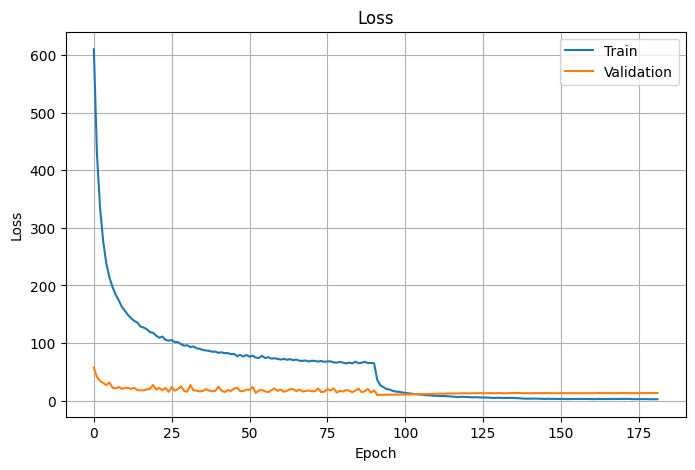

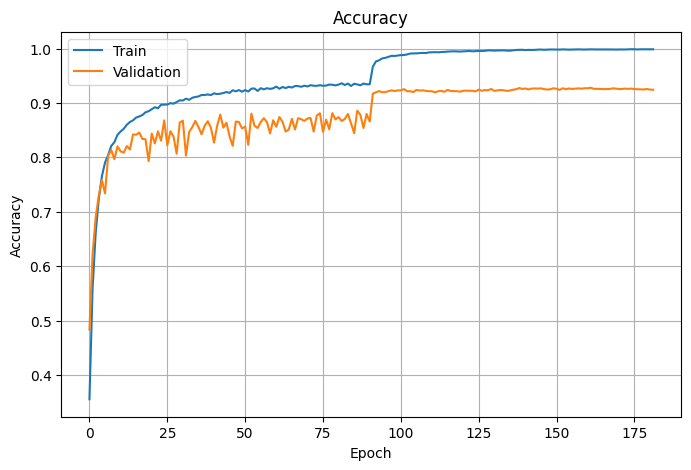

In [ ]:
import matplotlib.pyplot as plt

# Loss 그래프

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy 그래프

plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()